# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

---

### Dataset yang Digunakan: **Breast Cancer Wisconsin (Diagnostic) Dataset**

- **Sumber**: UCI Machine Learning Repository, juga tersedia via `sklearn.datasets.load_breast_cancer`.
- **Jumlah baris / kolom**: 569 baris × 31 kolom (30 fitur numerik + 1 target).
- **Deskripsi fitur**: 30 fitur numerik hasil pengukuran karakteristik nukleus sel dari biopsi jaringan payudara (mean, standard error, dan worst) dari 10 atribut dasar:
    - radius, texture, perimeter, area, smoothness
    - compactness, concavity, concave points, symmetry, fractal dimension
- **Target / Label**: `diagnosis_label` dengan 2 kelas — *malignant* (ganas) dan *benign* (jinak).
- **Tugas**: klasifikasi biner (binary classification).
- **Distribusi kelas**: 357 benign, 212 malignant (sedikit imbalanced).
- **Alasan memilih dataset ini**: dataset medis populer dengan fitur numerik yang kaya (30 fitur), sehingga cocok untuk demo pipeline preprocessing → modelling → CI → monitoring dengan domain real-world. Tidak termasuk dalam blacklist materi modul.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print('Semua library berhasil di-import.')


Semua library berhasil di-import.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan.

In [2]:
df = pd.read_csv('../breast_cancer_raw/breast_cancer.csv')

print('Shape dataset :', df.shape)
print('Jumlah kolom  :', df.shape[1])
df.head()


Shape dataset : (569, 31)
Jumlah kolom  : 31


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean_radius              569 non-null    float64
 1   mean_texture             569 non-null    float64
 2   mean_perimeter           569 non-null    float64
 3   mean_area                569 non-null    float64
 4   mean_smoothness          569 non-null    float64
 5   mean_compactness         569 non-null    float64
 6   mean_concavity           569 non-null    float64
 7   mean_concave_points      569 non-null    float64
 8   mean_symmetry            569 non-null    float64
 9   mean_fractal_dimension   569 non-null    float64
 10  radius_error             569 non-null    float64
 11  texture_error            569 non-null    float64
 12  perimeter_error          569 non-null    float64
 13  area_error               569 non-null    float64
 14  smoothness_error         5

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean_radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean_texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean_perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean_area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean_smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean_compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean_concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean_concave_points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean_symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean_fractal_dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

### 4.1 Cek Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== Missing Values (top 10) ===')
print(missing_df.head(10))
print(f"\nTotal missing: {df.isnull().sum().sum()}")


=== Missing Values (top 10) ===
                        Missing Count  Missing %
mean_radius                         0        0.0
mean_texture                        0        0.0
mean_perimeter                      0        0.0
mean_area                           0        0.0
mean_smoothness                     0        0.0
mean_compactness                    0        0.0
mean_concavity                      0        0.0
mean_concave_points                 0        0.0
mean_symmetry                       0        0.0
mean_fractal_dimension              0        0.0

Total missing: 0


### 4.2 Cek Data Duplikat

In [6]:
print('=== Data Duplikat ===')
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')


=== Data Duplikat ===
Jumlah baris duplikat: 0


### 4.3 Distribusi Target

=== Distribusi Target ===
diagnosis_label
benign       357
malignant    212
Name: count, dtype: int64

Proporsi:
diagnosis_label
benign       62.74
malignant    37.26
Name: proportion, dtype: float64


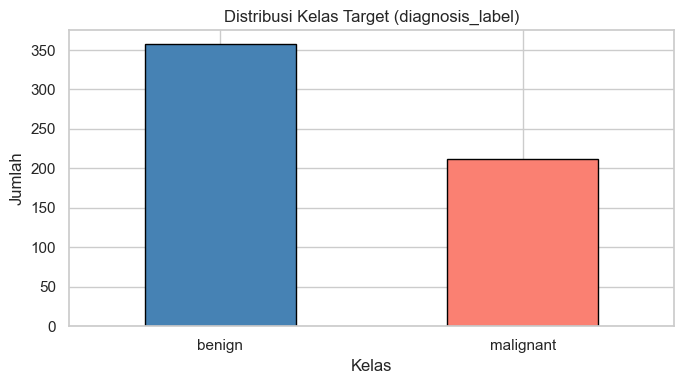

In [7]:
target_col = 'diagnosis_label'

print('=== Distribusi Target ===')
print(df[target_col].value_counts())
print('\nProporsi:')
print((df[target_col].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(7, 4))
df[target_col].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Distribusi Kelas Target (diagnosis_label)')
plt.xlabel('Kelas'); plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 4.4 Distribusi Fitur Numerik (10 fitur 'mean')

Jumlah fitur mean: 10


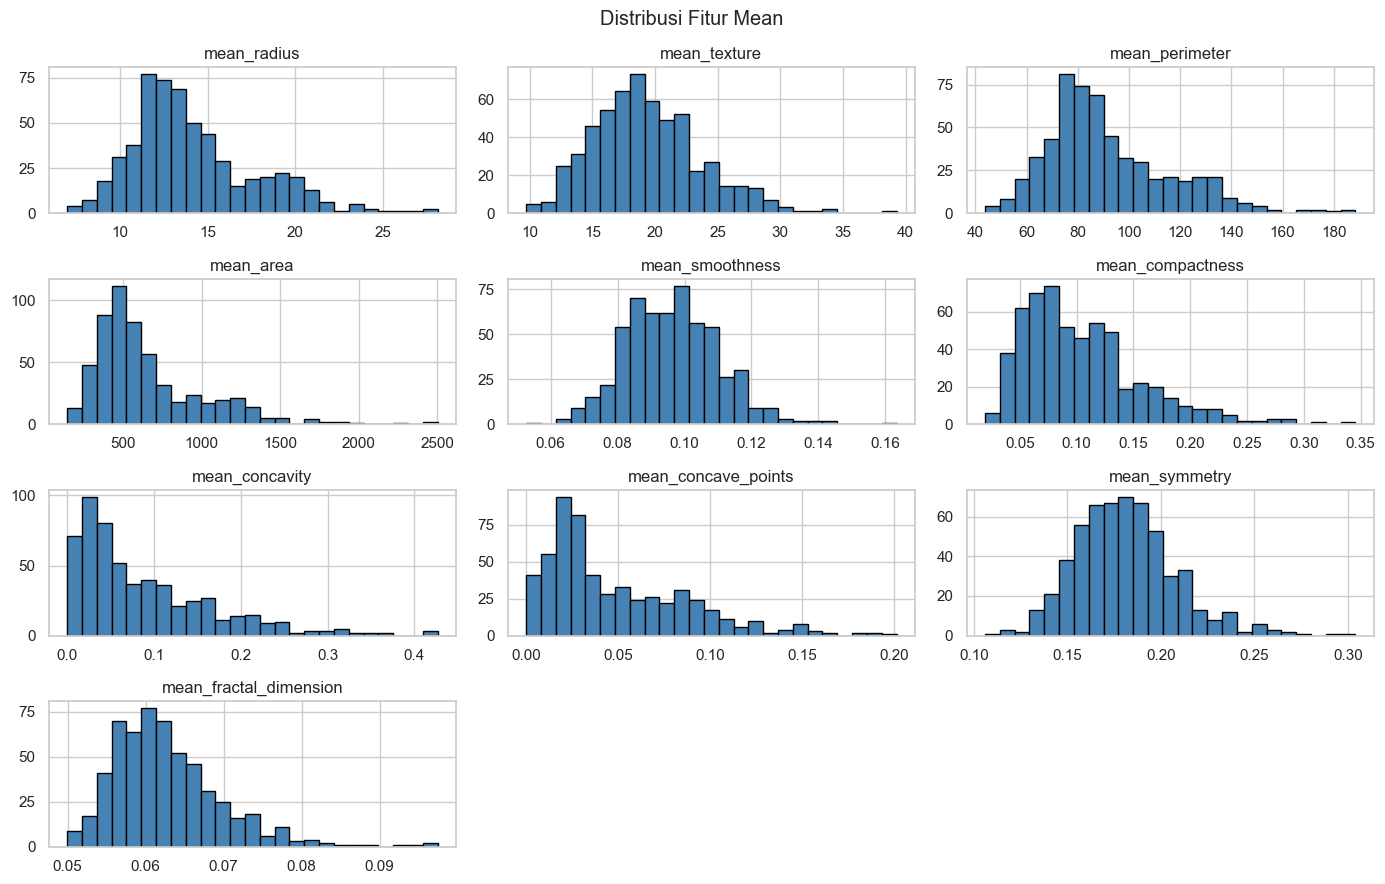

In [8]:
mean_features = [c for c in df.columns if c.startswith('mean_')]
print(f'Jumlah fitur mean: {len(mean_features)}')
df[mean_features].hist(figsize=(14, 9), bins=25, color='steelblue', edgecolor='black')
plt.suptitle('Distribusi Fitur Mean')
plt.tight_layout()
plt.show()


### 4.5 Heatmap Korelasi (10 fitur 'mean')

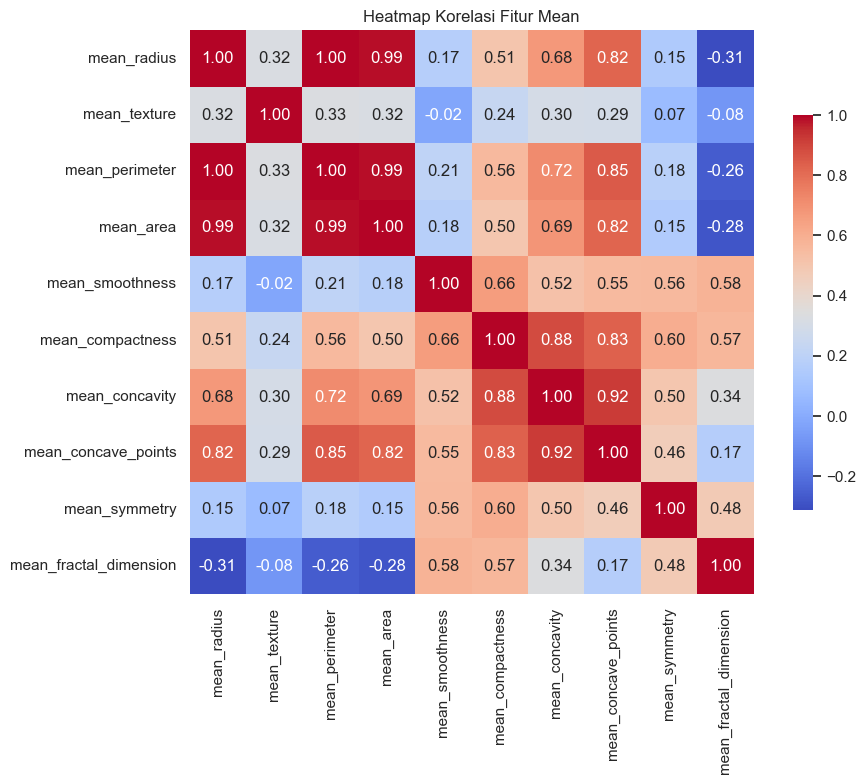

In [9]:
plt.figure(figsize=(10, 8))
corr_matrix = df[mean_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': 0.7})
plt.title('Heatmap Korelasi Fitur Mean')
plt.tight_layout()
plt.show()


### 4.6 Boxplot Outlier per Kelas

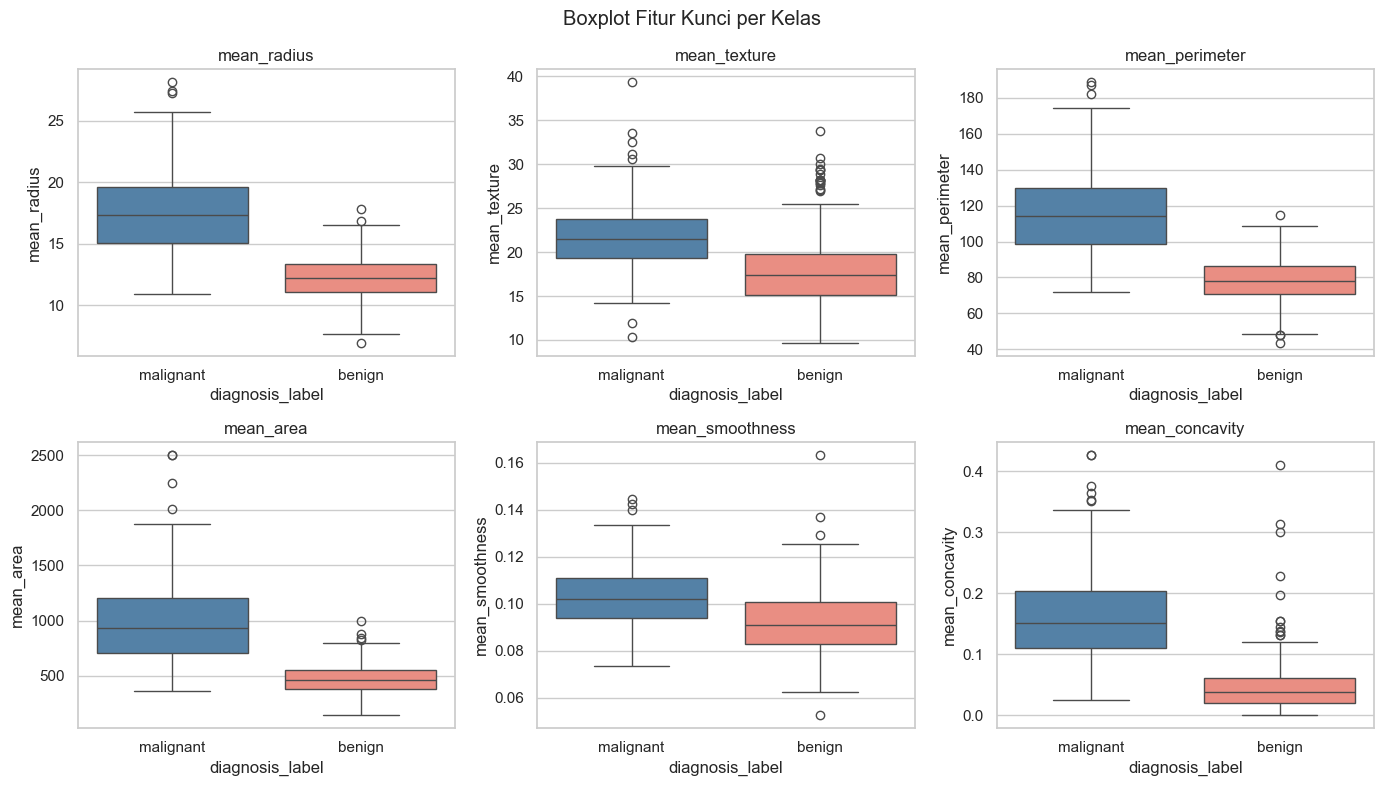

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
key_features = ['mean_radius', 'mean_texture', 'mean_perimeter',
                'mean_area', 'mean_smoothness', 'mean_concavity']
for ax, feat in zip(axes.flatten(), key_features):
    sns.boxplot(data=df, x=target_col, y=feat, ax=ax, palette=['steelblue', 'salmon'])
    ax.set_title(feat)
plt.suptitle('Boxplot Fitur Kunci per Kelas')
plt.tight_layout()
plt.show()


### 4.7 Scatter Pairplot (4 Fitur Kunci)

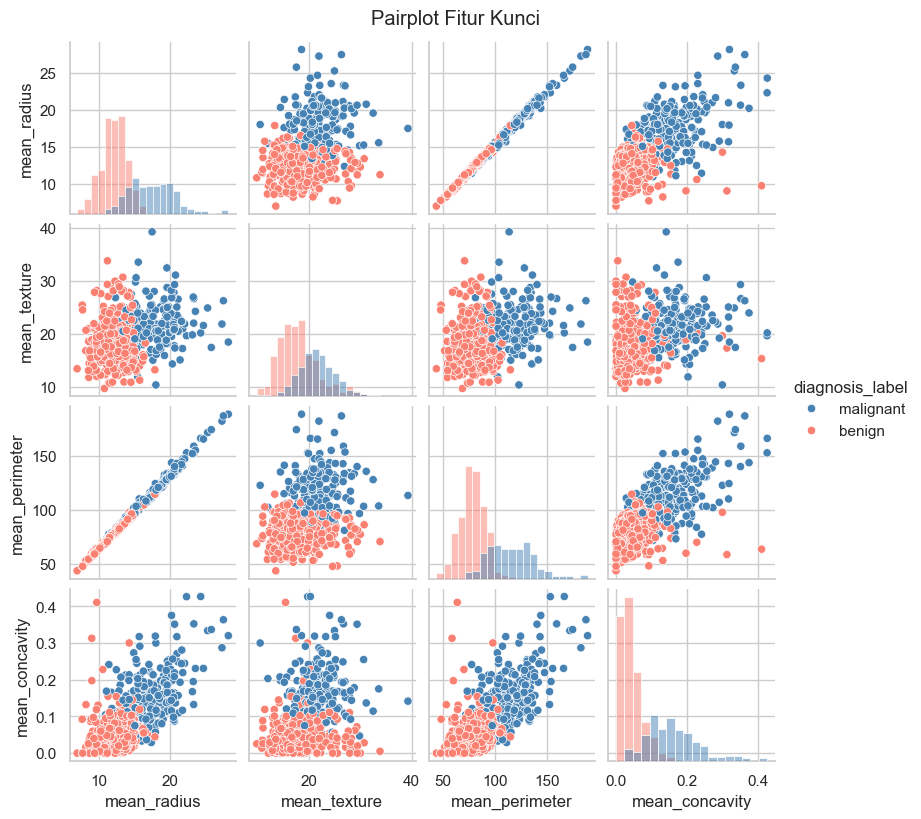

In [11]:
sub_cols = ['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_concavity', target_col]
sns.pairplot(df[sub_cols], hue=target_col, diag_kind='hist', height=2.0,
             palette=['steelblue', 'salmon'])
plt.suptitle('Pairplot Fitur Kunci', y=1.02)
plt.show()


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

### 5.1 Handle Missing Values

In [12]:
num_cols_feat = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_col]
cat_cols      = [c for c in df.select_dtypes(include=['object']).columns if c != target_col]

if num_cols_feat:
    num_imputer = SimpleImputer(strategy='median')
    df[num_cols_feat] = num_imputer.fit_transform(df[num_cols_feat])

if cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print(f'Missing values setelah handling: {df.isnull().sum().sum()}')


Missing values setelah handling: 0


### 5.2 Handle Duplikat

In [13]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after  = len(df)
print(f'Baris dihapus: {before - after} | Total sekarang: {after}')


Baris dihapus: 0 | Total sekarang: 569


### 5.3 Encoding Target Kategorikal

In [14]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f'  Encoded fitur kategorikal: {col}')

if df[target_col].dtype == 'object':
    target_le = LabelEncoder()
    df[target_col] = target_le.fit_transform(df[target_col])
    print(f'  Encoded target: {target_col} -> {dict(zip(target_le.classes_, range(len(target_le.classes_))))}')


  Encoded target: diagnosis_label -> {'benign': 0, 'malignant': 1}


### 5.4 Train-Test Split

In [15]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train distribusi:')
print(y_train.value_counts())


X_train: (455, 30) | X_test: (114, 30)
y_train distribusi:
diagnosis_label
0    285
1    170
Name: count, dtype: int64


### 5.5 Feature Scaling (StandardScaler)

In [16]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)
print('Scaling selesai.')
print('Statistik X_train_scaled (mean ~ 0, std ~ 1):')
X_train_scaled.describe().T[['mean', 'std']].head()


Scaling selesai.
Statistik X_train_scaled (mean ~ 0, std ~ 1):


,mean,std
mean_radius,-1.737316e-16,1.001101
mean_texture,3.904081e-16,1.001101
mean_perimeter,4.704418e-16,1.001101
mean_area,-1.171224e-16,1.001101
mean_smoothness,7.242070e-16,1.001101


### 5.6 Simpan Hasil Preprocessing

In [17]:
import pickle

output_dir = 'breast_cancer_preprocessing'
os.makedirs(output_dir, exist_ok=True)

X_train_scaled.to_csv(f'{output_dir}/X_train.csv', index=False)
X_test_scaled.to_csv(f'{output_dir}/X_test.csv',   index=False)
y_train.reset_index(drop=True).to_csv(f'{output_dir}/y_train.csv', index=False)
y_test.reset_index(drop=True).to_csv(f'{output_dir}/y_test.csv',   index=False)

with open(f'{output_dir}/scaler.pkl', 'wb') as f:
    pickle.dump({'scaler': scaler, 'feature_names': list(X_train.columns)}, f)

print(f"Preprocessing selesai! File disimpan di '{output_dir}/'")
print(f'  X_train  : {X_train_scaled.shape}')
print(f'  X_test   : {X_test_scaled.shape}')
print(f'  y_train  : {y_train.shape}')
print(f'  y_test   : {y_test.shape}')
print(f'  scaler.pkl tersimpan')


Preprocessing selesai! File disimpan di 'breast_cancer_preprocessing/'
  X_train  : (455, 30)
  X_test   : (114, 30)
  y_train  : (455,)
  y_test   : (114,)
  scaler.pkl tersimpan
